## FUNCTIONS

In [1]:
def lotfrontage_impute(X):
    medians = X.groupby('Neighborhood')['LotFrontage'].transform('median')
    X['LotFrontage'] = X['LotFrontage'].fillna(medians)
    return X 

def manual_ordinal_encoding(df):
    mappings = manual_mappings
    for col, mapping in mappings.items():
        df[col] = df[col].replace(mapping)
    return df

def custom_quantile_binning(df):
    variables = binning_col
    for var in variables:
        non_zero = df[var][df[var] != 0]
        q1 = non_zero.quantile(0.5)  
        df[var] = np.select(
            [
                df[var] == 0,
                (df[var] > 0) & (df[var] <= q1),
                df[var] > q1
            ],
            [0, 1, 2]
        )
    return df

def plot_metrics(model, X_train, y_train, X_test, y_test, name="Model"):
    """Calculates RMSE and R2 metrics, prints text and bar charts."""
    
    # Predictions and inverse logarithm
    y_tr_exp, y_te_exp = np.expm1(y_train), np.expm1(y_test)
    p_tr_exp, p_te_exp = np.expm1(model.predict(X_train)), np.expm1(model.predict(X_test))

    # Calculate metrics
    rmse_tr, rmse_te = np.sqrt(mean_squared_error(y_tr_exp, p_tr_exp)), np.sqrt(mean_squared_error(y_te_exp, p_te_exp))
    r2_tr, r2_te = r2_score(y_tr_exp, p_tr_exp), r2_score(y_te_exp, p_te_exp)

    print(f"--- {name} ---")
    print(f"R2 Diff: {(r2_tr - r2_te):.4f}\n")

    # Plots
    # --- R2 and RMSE ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    colors = ['tab:blue', 'tab:orange']

    ax1.bar(['Train', 'Test'], [r2_tr, r2_te], color=colors)
    ax1.set(title='R2 Score', ylim=(0, 1.1))
    ax1.grid(axis='y', linestyle='--', alpha=0.7)
    ax1.bar_label(ax1.containers[0], fmt='%.4f', padding=3)

    ax2.bar(['Train', 'Test'], [rmse_tr, rmse_te], color=colors)
    ax2.set(title='RMSE ($)', ylim=(0, max(rmse_tr, rmse_te) * 1.15))
    ax2.grid(axis='y', linestyle='--', alpha=0.7)
    ax2.bar_label(ax2.containers[0], labels=[f"{rmse_tr:,.0f}", f"{rmse_te:,.0f}"], padding=3)
    
    plt.tight_layout()
    plt.show()

def plot_feature_importances(model, X_train, name="Model"):
    """Extracts feature weights from the pipeline (accounting for SFS) and plots a bar chart."""
    preprocessor = model.named_steps['preprocessor']
    best_model = model.named_steps['model'].best_estimator_
    
    # Get column names after preprocessing 
    X_train_pre = preprocessor.transform(X_train)
    if hasattr(X_train_pre, 'columns'):
        feature_names = np.array(X_train_pre.columns)
    else:
        feature_names = preprocessor.get_feature_names_out()

    # Filter for SFS
    if 'sfs' in model.named_steps:
        sfs = model.named_steps['sfs']
        selected_idx = list(sfs.k_feature_idx_)
        feature_names = feature_names[selected_idx]
    else:
        feature_names = feature_names 

    importances = pd.Series(best_model.feature_importances_, index=feature_names)
    importances.sort_values(ascending=False, inplace=True)
    
    # Plotting
    plt.figure(figsize=(15, 5))
    importances.plot.bar(color='tab:blue')
    plt.title(f'{name} - Feature Importances', fontsize=12, fontweight='bold')
    plt.ylabel('Importance Weight')
    plt.xticks(rotation=90, fontsize=8) 
    sns.despine()
    plt.tight_layout()
    plt.show()

def plot_actual_vs_predicted(model, X_train, y_train, X_test, y_test, name="Model"):
    """Plots 'Actual vs Predicted' scatter plots for Train and Test."""
    
    # Predictions and inverse logarithm
    y_tr_exp, y_te_exp = np.expm1(y_train), np.expm1(y_test)
    p_tr_exp, p_te_exp = np.expm1(model.predict(X_train)), np.expm1(model.predict(X_test))

    fig, (ax_tr, ax_te) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Common limits for axes
    min_val = min(y_tr_exp.min(), y_te_exp.min(), p_tr_exp.min(), p_te_exp.min())
    max_val = max(y_tr_exp.max(), y_te_exp.max(), p_tr_exp.max(), p_te_exp.max())

    # Left plot - Train
    sns.scatterplot(x=y_tr_exp, y=p_tr_exp, alpha=0.5, color='tab:blue', ax=ax_tr)
    ax_tr.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
    ax_tr.set(title=f'{name} - Train: Actual vs Predicted', xlabel='Actual Value ($)', ylabel='Predicted Value ($)')
    ax_tr.grid(True, linestyle='--', alpha=0.5)

    # Right plot - Test
    sns.scatterplot(x=y_te_exp, y=p_te_exp, alpha=0.5, color='tab:orange', ax=ax_te)
    ax_te.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
    ax_te.set(title=f'{name} - Test: Actual vs Predicted', xlabel='Actual Value ($)', ylabel='Predicted Value ($)')
    ax_te.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, FunctionTransformer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

from feature_engine.imputation import CategoricalImputer, ArbitraryNumberImputer
from feature_engine.selection import SmartCorrelatedSelection

from category_encoders import CatBoostEncoder
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

import warnings

warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('../data/houseprice.csv')
df['SalePrice_log']  = np.log1p(df['SalePrice'])
print(df.shape)

(1460, 82)


## Removing Extreme Outliers (`GrLivArea < 4000`):

- This is the official recommendation from the creator of the Ames Housing dataset, Professor Dean De Cock.
- In his publication, he explained that houses exceeding 4,000 sq. ft. represent anomalous, non-market transactions (e.g., sales of massive unfinished homes at steep discounts) that distort predictive models.
- **[Link to Dean De Cock's original paper (PDF, page 4)](https://jse.amstat.org/v19n3/decock.pdf)**

In [4]:
df = df[df["GrLivArea"] < 4000]
df.shape

(1456, 82)

## Grouping Rare Categories
### Discrete

Since these features are ordinal, where values follow a clear sequence from worst to best or from lowest to highest, we **merge rare and underrepresented categories with their closest logical neighbors**.

In [5]:
df['OverallQual'] = df['OverallQual'].replace({1:4, 2:4, 3:4, 9:8, 10:8})
df['OverallCond'] = df['OverallCond'].replace({1:4, 2:4, 3:4, 9:8})
df['BsmtFullBath'] = df['BsmtFullBath'].replace({3:1, 2:1})
df['FullBath'] = df['FullBath'].replace({0:1, 3:2})
df['HalfBath'] = df['HalfBath'].replace(2,1)
df['BedroomAbvGr'] = df['BedroomAbvGr'].replace({0:2, 1:2, 5:4, 6:4, 8:4})
df['TotRmsAbvGrd'] = df['TotRmsAbvGrd'].replace({2:4, 3:4, 11:10, 12:10, 14:10})
df['Fireplaces'] = df['Fireplaces'].replace(3,2)
df['GarageCars'] = df['GarageCars'].replace(4,3)

### Ordinal Variables
- Similarly, we **merge rare categories with their closest logical neighbors**, but this time for text-based ordinal variables.
- Most of these features represent standard quality levels (Po — Poor, Fa — Fair, TA — Typical/Average, Gd — Good, Ex — Excellent).

In [6]:
df['LotShape'] = df['LotShape'].replace({'IR3': 'IR1', 'IR2': 'IR1'})
df['LandContour'] = df['LandContour'].replace('HLS', 'Low')
df['ExterQual'] = df['ExterQual'].replace({'Ex': 'Gd', 'Fa': 'TA'})
df['BsmtQual'] = df['BsmtQual'].replace('Fa', 'TA')
df['HeatingQC'] = df['HeatingQC'].replace({'Po': 'TA', 'Fa': 'TA'})
df['KitchenQual'] = df['KitchenQual'].replace('Fa', 'TA')
df['FireplaceQu'] = df['FireplaceQu'].replace({'Fa': 'TA', 'Po': 'TA', 'Ex': 'Gd'})
df['PavedDrive'] = df['PavedDrive'].replace('P', 'N')

### Nominal Variables
- Handling categorical variables that have no inherent logical order.
- Any value occurring in less than 3% of the observations is grouped into a single new category, 'Rare'.

In [7]:
df['MSSubClass'] = df['MSSubClass'].astype(str)
df['Electrical'] = df['Electrical'].fillna('Missing')

cat_cols_nominal = ['HouseStyle', 'Exterior1st', 'Exterior2nd', 'GarageType', 'SaleType', 'SaleCondition', 'MSZoning', 
                    'Electrical', 'MSSubClass', 'Foundation', 'MasVnrType', 'LotConfig', 'Condition1', 'Condition2']

for col in cat_cols_nominal:
    category_freq = df[col].value_counts() / len(df)
    rare_cats = category_freq[category_freq < 0.03].index
    df[col] = df[col].apply(lambda x: 'Rare' if x in rare_cats else x)

* The `Neighborhood` feature is handled separately, as it requires a distinct underlying logic.
* We group similar locations into three overarching market clusters:
    * **Townhouse:** Neighborhoods with compact, high-density housing.
    * **Historic:** Older university zones with unique pricing dynamics.
    * **Suburban:** Spacious suburban areas with large lot sizes.

In [8]:
neighborhood_mapping = {
    # Compact / High-density housing
    'NPkVill': 'Townhouse',
    'Blueste': 'Townhouse',
    'MeadowV': 'Townhouse',
    'BrDale':  'Townhouse',

    # Historic / University zone
    'IDOTRR': 'Historic',
    'SWISU':  'Historic',

    # Spacious suburban area
    'ClearCr': 'Suburban',
    'StoneBr': 'Suburban',
    'Veenker': 'Suburban',
    'Blmngtn': 'Suburban',
    'Timber':  'Suburban'
}

df['Neighborhood'] = df['Neighborhood'].replace(neighborhood_mapping)

## Feature Engineering
- **`TotalSF` (Total Square Footage):** The sum of the living area and the basement area.
- **`SF_per_Room`:** Represents the average square footage per room. A small constant (`1e-6`) is added to the denominator to prevent division by zero.
- **`TotalBathrooms` (Total Bathrooms):** A half-bath (`HalfBath`) is counted as 0.5.
- **`SinceRemod` (Age):** The number of years elapsed from the time of construction (or remodeling) until the sale of the house.

In [9]:
df['TotalSF'] = df['GrLivArea'] + df['TotalBsmtSF']
df['SF_per_Room'] = df['TotalSF'] / (df['TotRmsAbvGrd'] + 1e-6)
df['TotalBathrooms'] = df['FullBath'] + 0.5 * df['HalfBath'] + df['BsmtFullBath'] + 0.5 * df['BsmtHalfBath']
df['SinceRemod'] = df['YrSold'] - df['YearBuilt']

In [10]:
cols = [
    # continuous
    'SinceRemod', 'TotalBathrooms', 'SF_per_Room', 'TotalSF', 'LotFrontage', 'LotArea', 'MasVnrArea', 'BsmtFinSF1', 
    'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'GrLivArea', 'YearBuilt', 'GarageArea', 'GarageYrBlt',
    # discrete
    'MSSubClass', 'OverallQual', 'OverallCond', 'BsmtFullBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageCars', 
    # ordinal
    'LotShape', 'LandContour', 'ExterQual', 'BsmtQual', 'BsmtExposure', 'BsmtFinType1', 'HeatingQC', 
    'CentralAir', 'Electrical', 'KitchenQual', 'FireplaceQu', 'GarageFinish', 'PavedDrive', 
    # nominal
    'MSZoning', 'LotConfig', 'BldgType', 'HouseStyle', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 
    'Foundation', 'GarageType', 'SaleType', 'SaleCondition', 'Neighborhood', 
    # Target
    'SalePrice_log'
    ]

In [11]:
df = df[cols]
df.shape

(1456, 52)

## Train-Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    df.drop('SalePrice_log', axis=1),
    df['SalePrice_log'],
    test_size=0.3,
    random_state=0
)

X_train.shape, X_test.shape

((1019, 51), (437, 51))

## Pipeline
- **Missing Value Imputation:** Missing values are filled with zeros for numerical features and placed into a new `'Missing'` category for categorical ones. A missing value (`NaN`) in these variables indicates the physical absence of a feature (e.g., the house simply does not have a fireplace, garage, or basement).
- **Encoding:** We apply manual ordinal encoding for features with an inherent logical order (using the `manual_mappings` dictionary) and target encoding (`CatBoostEncoder`) for nominal categories.
- **Discretization:** The `MasVnrArea` (masonry veneer area) feature is discretized, accounting for the fact that many houses have no veneer at all (0 = no veneer). 
- **Contextual Imputation:** For `LotFrontage` (linear feet of street connected to property), we impute missing values using the median of each `Neighborhood`, as houses within the same district are typically built to a uniform standard.
- **Removing Multicollinearity:** `SmartCorrelatedSelection` identifies highly correlated features (coefficient > 0.8) and retains only those that yield the best score on a baseline Random Forest model.

In [13]:
missing_cat_cols = ['MasVnrType', 'FireplaceQu', 'GarageType', 'GarageFinish', 'BsmtExposure', 'BsmtQual', 'BsmtFinType1']

missing_zero_cols = ['MasVnrArea', 'GarageYrBlt']

catboost_cols = [
    'MSSubClass', 'OverallCond', 'LandContour', 'BsmtFinType1', 'MSZoning', 'BldgType', 'HouseStyle', 'Exterior1st',
    'Exterior2nd', 'Foundation', 'GarageType', 'SaleType', 'Neighborhood', 'MasVnrType', 'SaleCondition', 'Electrical', 'LotConfig']

manual_mappings = {
    'LotShape': {'Reg': 0, 'IR1': 1},
    'ExterQual': {'TA': 0, 'Gd': 1},
    'BsmtQual': {'Missing': 0, 'TA': 1, 'Gd': 2, 'Ex': 3},
    'BsmtExposure': {'Missing': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4},
    'HeatingQC': {'TA': 0, 'Gd': 1, 'Ex': 2},
    'CentralAir': {'N': 0, 'Y': 1},
    'Electrical': {'Rare': 0, 'SBrkr': 1},
    'KitchenQual': {'TA': 0, 'Gd': 1, 'Ex': 2},
    'FireplaceQu': {'Missing': 0, 'TA': 1, 'Gd': 2},
    'GarageFinish': {'Missing': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3},
    'PavedDrive': {'N': 0, 'Y': 1},
    'LotConfig': {'FR2': 0, 'FR3': 1}
}

binning_col = ['MasVnrArea']

preprocessor = Pipeline([
    ('cat_imputer', CategoricalImputer(variables=missing_cat_cols)),
    ('arbitrary_imputer', ArbitraryNumberImputer(arbitrary_number=0, variables=missing_zero_cols)),
    ('lotfrontage_imputer', FunctionTransformer(lotfrontage_impute, validate=False)),
    ('catboost_encoder', CatBoostEncoder(cols=catboost_cols, return_df=True, random_state=0)),
    ('ordinal_encoder', FunctionTransformer(manual_ordinal_encoding, validate=False)),
    ('quantile_bisc', FunctionTransformer(custom_quantile_binning, validate=False)),
    ('corr_selector', SmartCorrelatedSelection(method='pearson', threshold=0.8, selection_method='model_performance',
                                              estimator=RandomForestRegressor(n_estimators=100, random_state=0),
                                              scoring='neg_root_mean_squared_error', cv=3))
])

models = {
    'RandomForest': RandomForestRegressor(random_state=0),
    'GradientBoosting': GradientBoostingRegressor(random_state=0),
    'XGBoost': XGBRegressor(random_state=0),
    'LightGBM': LGBMRegressor(random_state=0, verbose=-1),
    'CatBoost': CatBoostRegressor(random_state=0, verbose=0)
}

param_grid = {
    'RandomForest': {
        'n_estimators': [200, 300, 500],
        'max_depth': [3, 5, 7],
        'max_features': ['sqrt', 'log2']
    },
    'GradientBoosting': {
        'n_estimators': [200, 300, 500],
        'learning_rate': [0.01, 0.03, 0.1],
        'max_depth': [3, 5]
    },
    'XGBoost': {
        'n_estimators': [200, 300, 500],
        'learning_rate': [0.01, 0.03, 0.1],
        'max_depth': [3, 5]
    },
    'LightGBM': {
        'n_estimators': [200, 300, 500],
        'learning_rate': [0.01, 0.03, 0.1],
        'max_depth': [3, 5]
    },
    'CatBoost': {
        'n_estimators': [200, 300, 500],
        'learning_rate': [0.01, 0.03, 0.1],
        'depth': [3, 5]
    }
}

## Model Training & Validation
### Random Forest 

--- RandomForest ---
R2 Diff: 0.0434



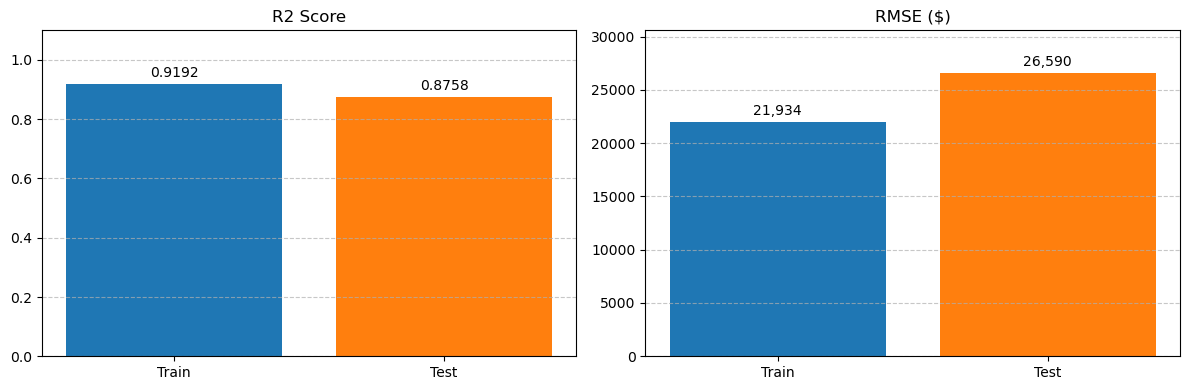

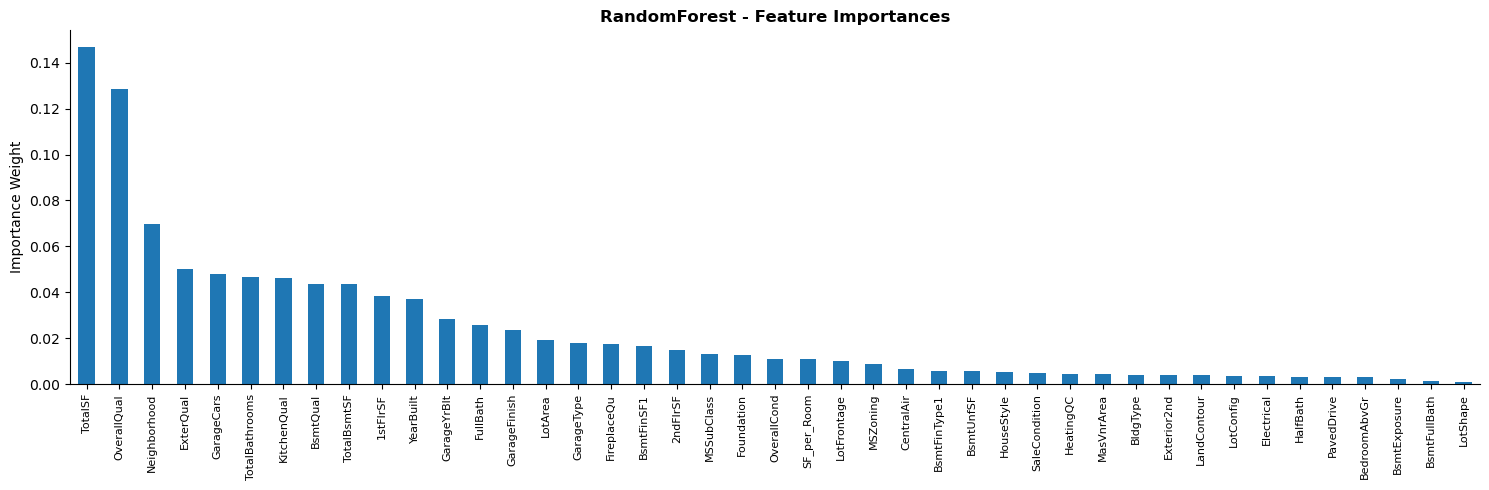

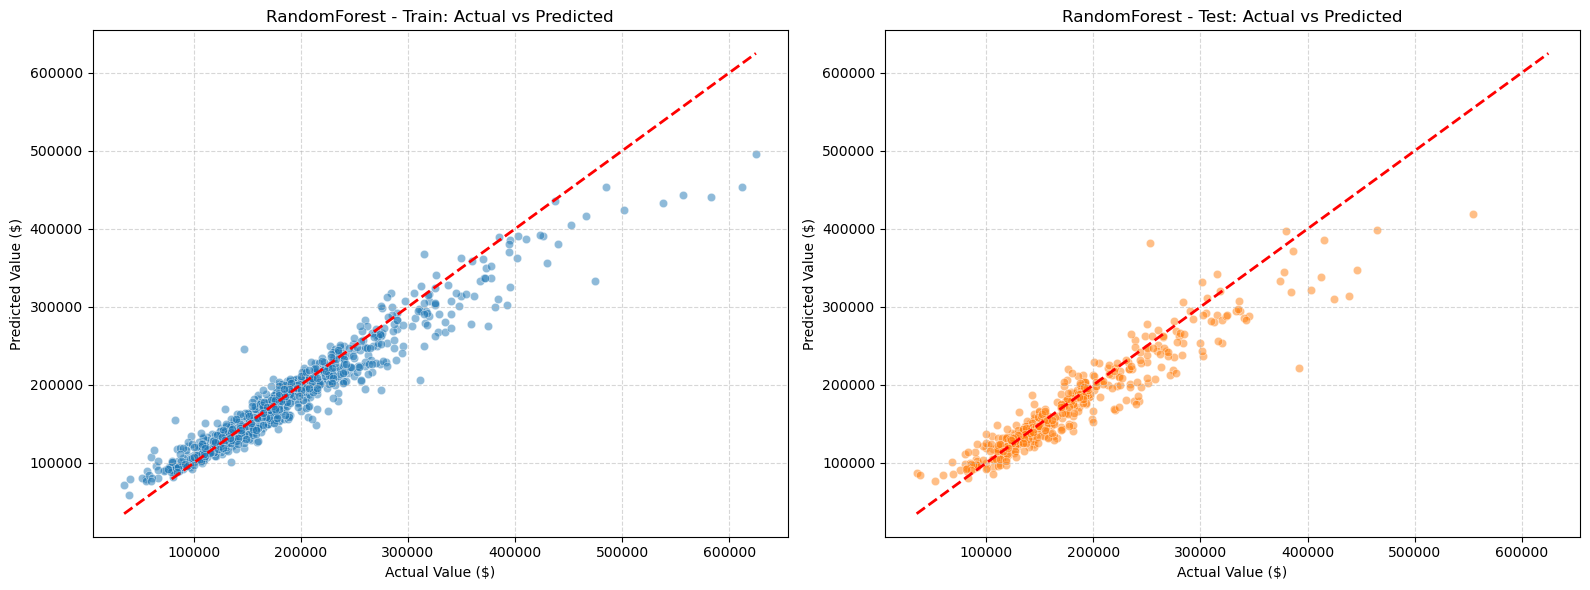

{'max_depth': 7, 'max_features': 'sqrt', 'n_estimators': 500}

In [14]:
selected_model = 'RandomForest'
model = models[selected_model]
grid = GridSearchCV(model, param_grid=param_grid[selected_model],
                   scoring='neg_root_mean_squared_error', cv=5)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', grid)
])

pipeline.fit(X_train, y_train)

plot_metrics(pipeline, X_train, y_train, X_test, y_test, name=selected_model)
plot_feature_importances(pipeline, X_train, name=selected_model)
plot_actual_vs_predicted(pipeline, X_train, y_train, X_test, y_test, name=selected_model)
pipeline.named_steps['model'].best_params_

- The most important features are the engineered `TotalSF` (total square footage), `OverallQual` (overall quality), and `Neighborhood`.
- Looking at the scatter plot, it is evident that the model systematically underestimates houses priced above $400k, attempting to average them with their less expensive neighbors.

### Boosting Models: GBM, XGBoost, and LightGBM

--- GradientBoosting ---
R2 Diff: 0.0395



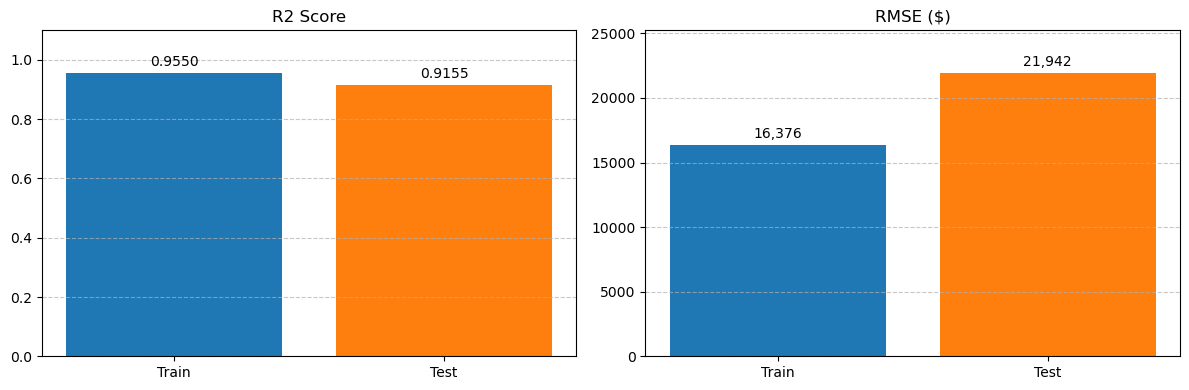

{'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 300}

In [15]:
selected_model = 'GradientBoosting'
model = models[selected_model]
grid = GridSearchCV(model, param_grid=param_grid[selected_model],
                   scoring='neg_root_mean_squared_error', cv=5)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', grid)
])

pipeline.fit(X_train, y_train)

plot_metrics(pipeline, X_train, y_train, X_test, y_test, name=selected_model)
pipeline.named_steps['model'].best_params_

Transitioning to gradient boosting yielded an immediate performance boost, with the average error (RMSE) dropping by 4k–5k.

--- XGBoost ---
R2 Diff: 0.0362



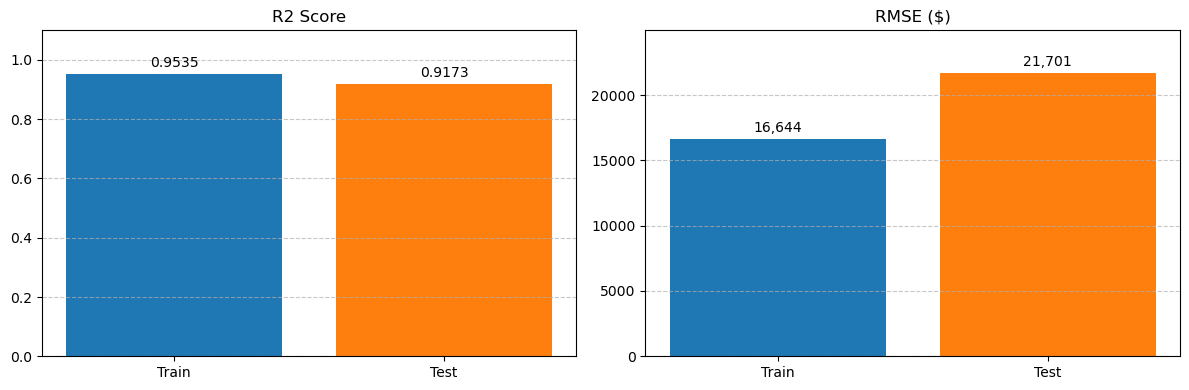

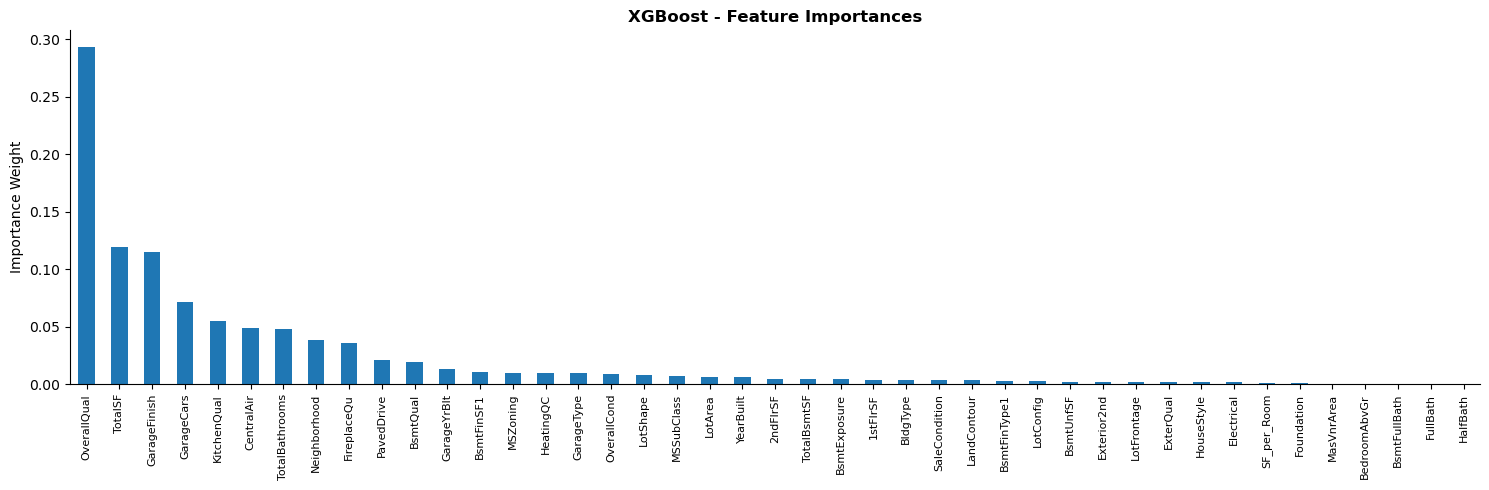

{'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 300}

In [16]:
selected_model = 'XGBoost'
model = models[selected_model]
grid = GridSearchCV(model, param_grid=param_grid[selected_model],
                   scoring='neg_root_mean_squared_error', cv=5)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', grid)
])

pipeline.fit(X_train, y_train)

plot_metrics(pipeline, X_train, y_train, X_test, y_test, name=selected_model)
plot_feature_importances(pipeline, X_train, name=selected_model)
pipeline.named_steps['model'].best_params_

- XGBoost assigned nearly 30% of its feature importance to a single variable — `OverallQual`, pushing total area to second place. The other models maintained the lead for `TotalSF`(total area).
- Nevertheless, the core set of top features (Area, Quality, Neighborhood, Age, and Garage) remains consistent.

--- LightGBM ---
R2 Diff: 0.0314



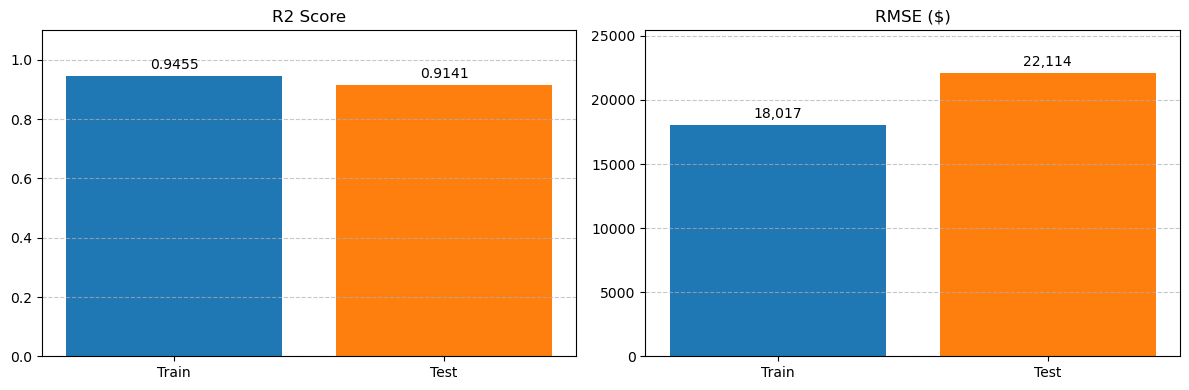

{'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 300}

In [17]:
selected_model = 'LightGBM'
model = models[selected_model]
grid = GridSearchCV(model, param_grid=param_grid[selected_model],
                   scoring='neg_root_mean_squared_error', cv=5)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', grid)
])

pipeline.fit(X_train, y_train)

plot_metrics(pipeline, X_train, y_train, X_test, y_test, name=selected_model)
pipeline.named_steps['model'].best_params_

### CatBoost

--- CatBoost ---
R2 Diff: 0.0290



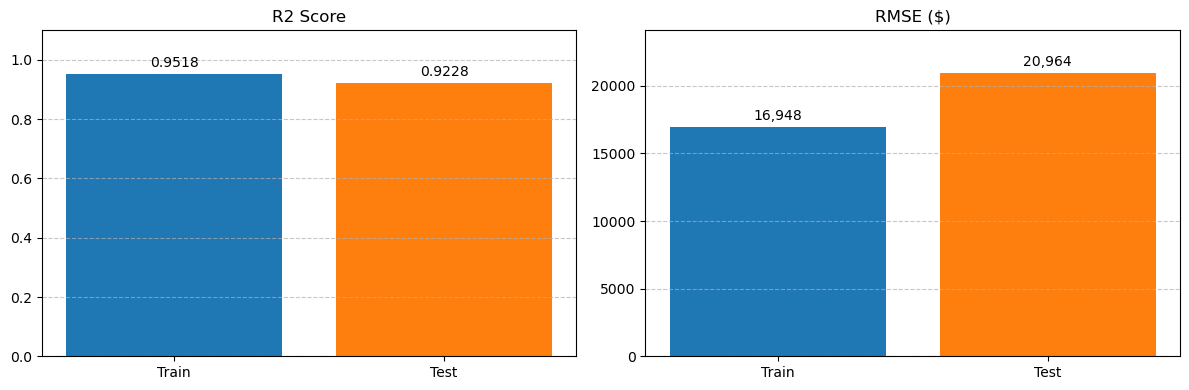

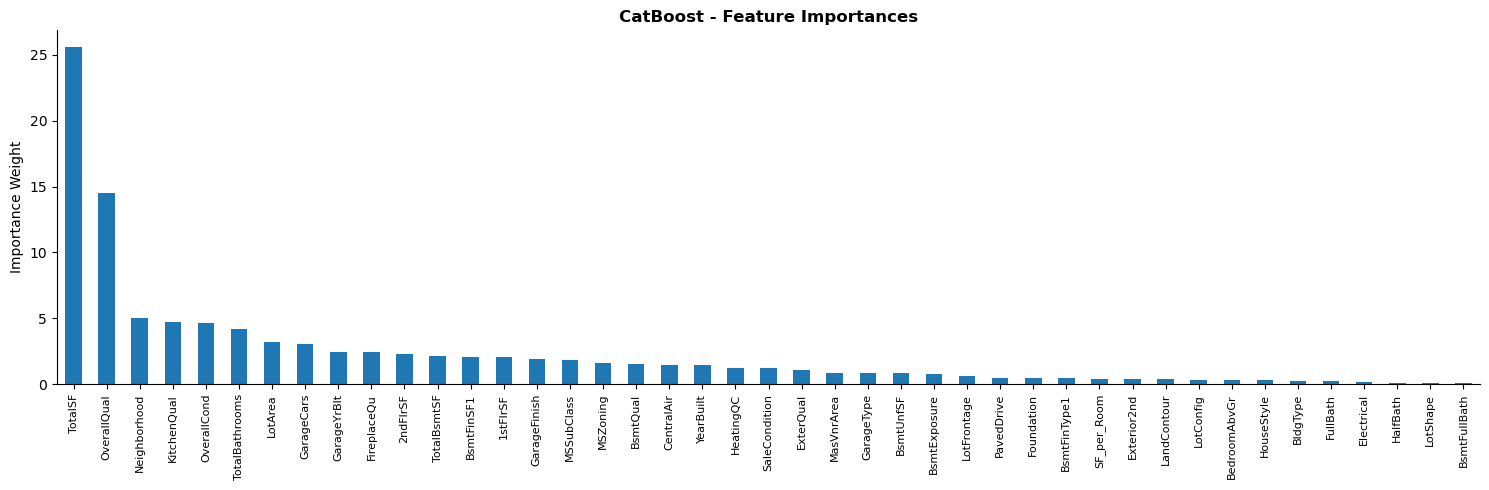

{'depth': 5, 'learning_rate': 0.03, 'n_estimators': 500}

In [18]:
selected_model = 'CatBoost'
model = models[selected_model]
grid = GridSearchCV(model, param_grid=param_grid[selected_model],
                   scoring='neg_root_mean_squared_error', cv=5)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', grid)
])

pipeline.fit(X_train, y_train)

plot_metrics(pipeline, X_train, y_train, X_test, y_test, name=selected_model)
plot_feature_importances(pipeline, X_train, name=selected_model)
pipeline.named_steps['model'].best_params_

- CatBoost achieved the best performance among all models.
- The `TotalSF` feature reclaimed the top spot in feature importance.

### Adding Feature Selection Step

--- CatBoost ---
R2 Diff: 0.0246



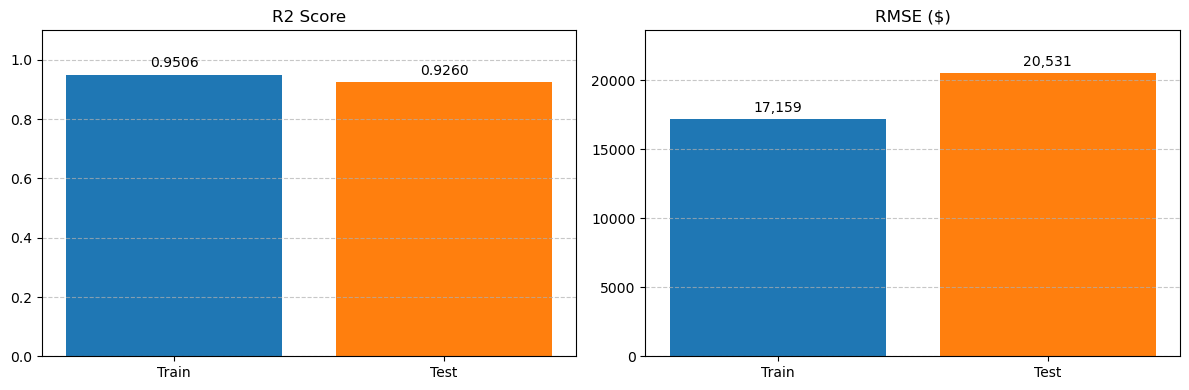

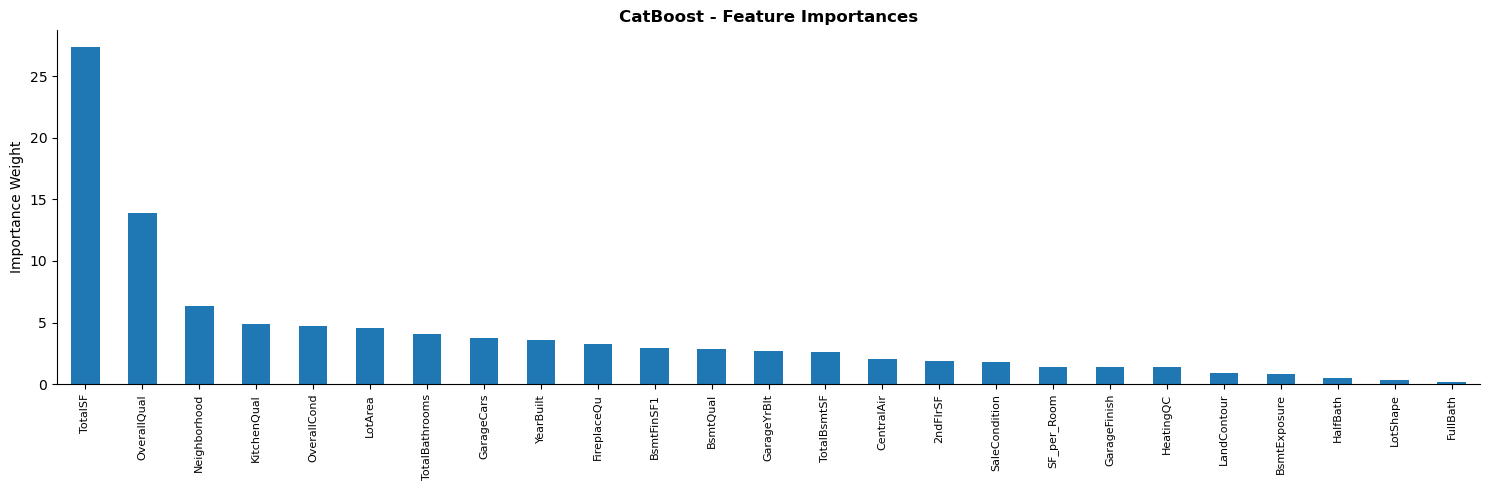

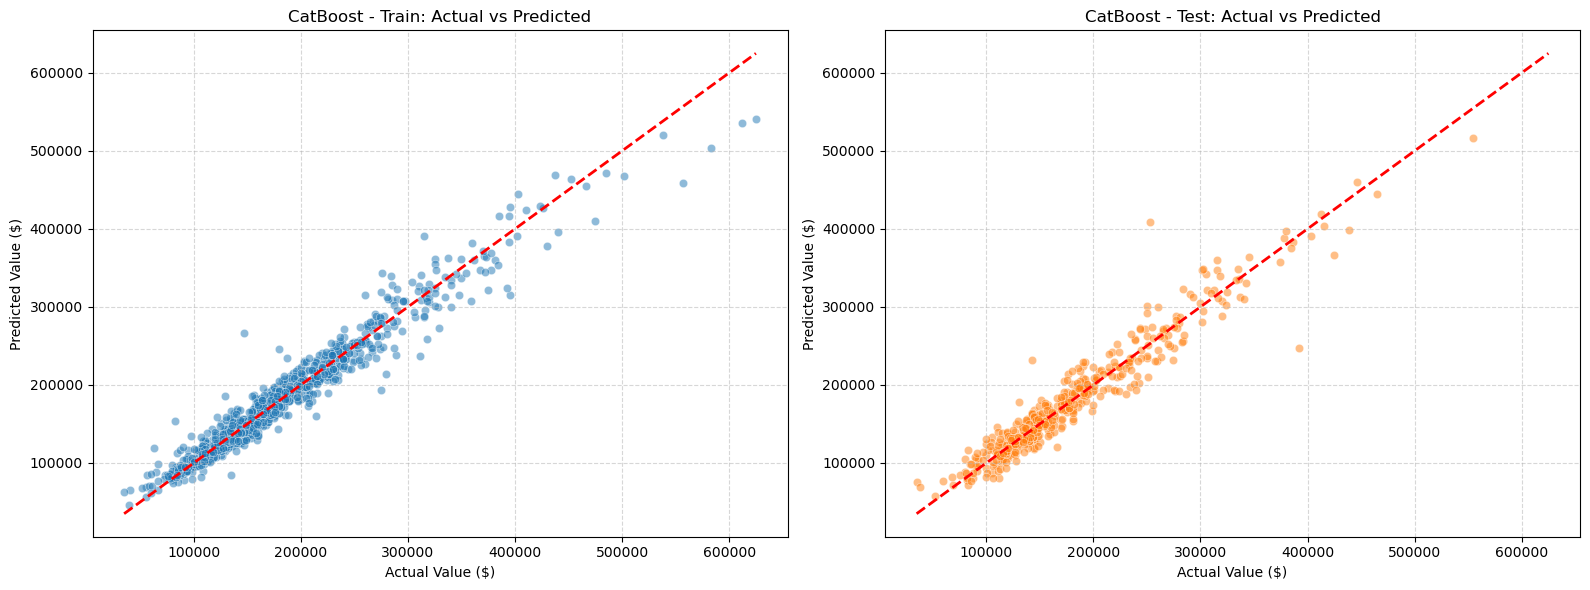

In [19]:
selected_model = 'CatBoost'
model = models[selected_model]

sfs_estimator = CatBoostRegressor(n_estimators=500, random_state=0, depth=5, learning_rate=0.03, verbose=False, allow_writing_files=False) 

sfs = SFS(
    estimator=sfs_estimator,
    k_features='best', 
    forward=False,      
    floating=True,
    scoring='neg_root_mean_squared_error',
    cv=3,              
    n_jobs=-1          
)

grid = GridSearchCV(model, param_grid=param_grid[selected_model], scoring='neg_root_mean_squared_error', cv=5, n_jobs=-1)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('sfs', sfs), 
    ('model', grid)
])

pipeline.fit(X_train, y_train)
plot_metrics(pipeline, X_train, y_train, X_test, y_test, name=selected_model)
plot_feature_importances(pipeline, X_train, name=selected_model)
plot_actual_vs_predicted(pipeline, X_train, y_train, X_test, y_test, name=selected_model)

- A Sequential Feature Selector (SFS) was added to the best model to reduce the number of features and eliminate informational "noise".
- The gap between the Train and Test scores became minimal (`R2 Drop = 0.0246`).
- The final feature importance plot became clean and concise, retaining only the most informative variables. On the scatter plot, luxury homes on the far right no longer exhibit systematic underestimation.
- The model now confidently predicts high-value transactions.
- The `R2 Diff` metric decreased from 0.0434 (Random Forest) to 0.0246 (CatBoost + SFS).

In [20]:
y_test_exp = np.expm1(y_test)
y_pred_test_exp = np.expm1(pipeline.predict(X_test))

# Results DataFrame
analysis_df = pd.DataFrame({
    'ActualPrice': y_test_exp,
    'PredictedPrice': y_pred_test_exp,
    'AbsError$': np.abs(y_test_exp - y_pred_test_exp) 
}, index=X_test.index)

# Concatenate metrics with the original features
outliers_df = pd.concat([analysis_df, X_test], axis=1)

top_outliers = outliers_df.sort_values(by='AbsError$', ascending=False).head(10)

columns_to_show = [
    'ActualPrice', 'PredictedPrice', 'AbsError$', 'TotalSF', 'OverallQual', 'Neighborhood', 'KitchenQual', 'OverallCond', 'LotArea', 
    'TotalBathrooms', 'GarageCars', 'YearBuilt', 'FireplaceQu', 'BsmtFinSF1', 'BsmtQual', 'GarageYrBlt', 'TotalBsmtSF', 'CentralAir',
    '2ndFlrSF', 'SaleCondition', 'SF_per_Room', 'GarageFinish', 'HeatingQC', 'LandContour', 'BsmtExposure', 'HalfBath', 'LotShape', 
    'FullBath', 'BsmtUnfSF']

top_outliers[columns_to_show]

,ActualPrice,PredictedPrice,AbsError$,TotalSF,OverallQual,Neighborhood,KitchenQual,OverallCond,LotArea,TotalBathrooms,...,SaleCondition,SF_per_Room,GarageFinish,HeatingQC,LandContour,BsmtExposure,HalfBath,LotShape,FullBath,BsmtUnfSF
581,253293.0,409329.234804,156036.234804,4084,8,NridgHt,Ex,5,12704,2.5,...,Partial,510.499936,RFn,Ex,Lvl,No,1,Reg,2,2042
688,392000.0,247353.604937,144646.395063,2838,8,Suburban,Gd,6,8089,3.0,...,Partial,405.428514,RFn,Ex,Low,Av,0,Reg,2,474
588,143000.0,231340.337298,88340.337298,2910,5,Suburban,Ex,8,25095,2.0,...,Partial,581.999884,Unf,Ex,Low,Gd,0,IR1,1,113
1142,424870.0,367058.355028,57811.644972,4294,8,CollgCr,Gd,5,9965,3.0,...,Partial,429.399957,RFn,Ex,Lvl,Gd,0,Reg,2,316
4,250000.0,301610.563951,51610.563951,3343,8,NoRidge,Gd,5,14260,3.5,...,Normal,371.444403,RFn,Ex,Lvl,Av,1,IR1,2,490
714,130500.0,177538.361241,47038.361241,2204,6,Sawyer,Gd,8,13517,2.5,...,Normal,367.333272,RFn,Ex,Lvl,No,1,IR1,2,192
1312,302000.0,348518.998502,46518.998502,4263,8,NoRidge,Gd,5,9572,2.5,...,Normal,473.666614,RFn,Ex,Lvl,No,1,IR1,2,971
848,240000.0,193897.416746,46102.583254,3265,6,Suburban,TA,8,45600,2.0,...,Normal,326.499967,Unf,TA,Bnk,No,0,IR1,2,907
1256,301500.0,347287.639312,45787.639312,3973,8,NoRidge,Gd,5,14303,3.0,...,Normal,567.571347,Fin,Ex,Lvl,Gd,0,IR1,2,672
142,166000.0,120212.636719,45787.363281,2295,5,NAmes,TA,4,8520,2.0,...,Normal,382.499936,Unf,TA,Lvl,No,0,Reg,2,403


- 4 out of the 5 largest errors are transactions with the `SaleCondition = Partial` status.

Let's look at the first row (`NridgHt` neighborhood):
- This house has a massive area (`TotalSF = 4084`), high overall quality (`8`), is brand new (`2008`), has a 3-car garage (`GarageCars = 3`), and a top-tier kitchen (`KitchenQual = Ex`).
- The model predicts a price of 409k, treating it as a luxury home.
- However, it was actually sold for 253k.
- There is no second floor (`2ndFlrSF = 0`); it is a single-story house. This means the 4,084 square feet are split in half: 2,042 sq. ft. for the first floor, and 2,042 sq. ft. for the basement.
- `BsmtUnfSF = 2042`! Half of this giant "luxury" house is an absolutely empty, bare, unfinished concrete basement.
- The model saw the total figure of 4,084, applied the high-end neighborhood coefficients, and output a forecast of $409k.
- But in reality, the buyer was paying for 2,000 square feet of actual living space and 2,000 square feet of an underground concrete "box".